# 05 — Análises e Exportação dos CSVs
## Pipeline ETL End-to-End — Olist E-commerce Dataset

Etapa final: lê os dados da camada TRUSTED e gera os CSVs
analíticos para o dashboard Streamlit.

**CSVs gerados:**
1. `receita_mensal.csv`
2. `performance_categorias.csv`
3. `satisfacao_estados.csv`
4. `tempo_entrega.csv`
5. `performance_vendedores.csv`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

TRUSTED_PATH = "/content/data_lake/trusted"
EXPORT_PATH  = "/content/export"
os.makedirs(EXPORT_PATH, exist_ok=True)

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("✅ Ambiente configurado")
print(f"   TRUSTED: {TRUSTED_PATH}")
print(f"   Exportações: {EXPORT_PATH}")

✅ Ambiente configurado
   TRUSTED: /content/data_lake/trusted
   Exportações: /content/export


In [ ]:
# Verifica se a camada TRUSTED existe — recriar se necessário
if not os.path.exists(f"{TRUSTED_PATH}/fato_pedidos"):
    print("⚠️  Camada TRUSTED não encontrada — recriando pipeline completo...")
    print("   Isso pode levar alguns minutos.")

    !pip install kagglehub pyspark -q

    import kagglehub
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F
    from pyspark.sql.types import *
    from datetime import datetime

    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

    LAKE_PATH = "/content/data_lake"
    RAW_PATH  = f"{LAKE_PATH}/raw"
    for folder in [RAW_PATH, TRUSTED_PATH]:
        os.makedirs(folder, exist_ok=True)

    # ── Ingestão RAW ────────────────────────────────────────────
    TABLES = {
        "olist_customers_dataset.csv":           "customers",
        "olist_sellers_dataset.csv":             "sellers",
        "olist_orders_dataset.csv":              "orders",
        "olist_order_items_dataset.csv":         "order_items",
        "olist_order_payments_dataset.csv":      "order_payments",
        "olist_order_reviews_dataset.csv":       "order_reviews",
        "olist_products_dataset.csv":            "products",
        "olist_geolocation_dataset.csv":         "geolocation",
        "product_category_name_translation.csv": "category_translation"
    }
    for csv_file, table_name in TABLES.items():
        df = pd.read_csv(f"{path}/{csv_file}")
        df["_ingested_at"] = datetime.now().isoformat()
        df["_source_file"] = csv_file
        table_path = f"{RAW_PATH}/{table_name}"
        os.makedirs(table_path, exist_ok=True)
        df.to_parquet(f"{table_path}/data.parquet", index=False)
        print(f"   ✅ RAW: {table_name:<25} {len(df):>10,} linhas")

    # ── Processamento TRUSTED ────────────────────────────────────
    spark = SparkSession.builder \
        .appName("olist-etl-recovery") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")

    customers_s  = spark.read.parquet(f"{RAW_PATH}/customers")
    sellers_s    = spark.read.parquet(f"{RAW_PATH}/sellers")
    orders_s     = spark.read.parquet(f"{RAW_PATH}/orders")
    items_s      = spark.read.parquet(f"{RAW_PATH}/order_items")
    payments_s   = spark.read.parquet(f"{RAW_PATH}/order_payments")
    reviews_s    = spark.read.parquet(f"{RAW_PATH}/order_reviews")
    products_s   = spark.read.parquet(f"{RAW_PATH}/products")
    geo_s        = spark.read.parquet(f"{RAW_PATH}/geolocation")
    category_s   = spark.read.parquet(f"{RAW_PATH}/category_translation")

    date_cols = [
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
    orders_clean = orders_s
    for col in date_cols:
        orders_clean = orders_clean.withColumn(col, F.to_timestamp(F.col(col)))
    orders_clean = orders_clean \
        .withColumn("purchase_year",    F.year("order_purchase_timestamp")) \
        .withColumn("purchase_month",   F.month("order_purchase_timestamp")) \
        .withColumn("purchase_day",     F.dayofmonth("order_purchase_timestamp")) \
        .withColumn("purchase_weekday", F.dayofweek("order_purchase_timestamp")) \
        .withColumn("delivery_days",
            F.datediff("order_delivered_customer_date", "order_purchase_timestamp")) \
        .withColumn("is_late",
            F.when(F.col("order_delivered_customer_date") >
                   F.col("order_estimated_delivery_date"), 1).otherwise(0)) \
        .filter(F.col("order_status").isNotNull()) \
        .drop("_ingested_at", "_source_file")

    items_clean = items_s \
        .withColumn("price",         F.col("price").cast(DoubleType())) \
        .withColumn("freight_value", F.col("freight_value").cast(DoubleType())) \
        .withColumn("total_value",   F.col("price") + F.col("freight_value")) \
        .filter(F.col("price") > 0) \
        .drop("_ingested_at", "_source_file")

    payments_clean = payments_s \
        .withColumn("payment_value", F.col("payment_value").cast(DoubleType())) \
        .withColumn("payment_installments", F.col("payment_installments").cast(IntegerType())) \
        .filter(F.col("payment_type").isNotNull() & (F.col("payment_value") > 0)) \
        .drop("_ingested_at", "_source_file")

    reviews_clean = reviews_s \
        .withColumn("review_score", F.col("review_score").cast(IntegerType())) \
        .filter(F.col("review_score").isNotNull()) \
        .select("review_id", "order_id", "review_score") \
        .drop("_ingested_at", "_source_file")

    products_clean = products_s \
        .join(category_s.select("product_category_name", "product_category_name_english"),
              on="product_category_name", how="left") \
        .fillna("unknown", subset=["product_category_name_english"]) \
        .drop("_ingested_at", "_source_file")

    geo_clean = geo_s \
        .dropDuplicates(["geolocation_zip_code_prefix"]) \
        .drop("_ingested_at", "_source_file")

    fato = orders_clean \
        .join(items_clean.select(
            "order_id",
            F.col("price").alias("item_price"),
            F.col("freight_value").alias("item_freight"),
            F.col("total_value").alias("item_total"),
            "product_id", "seller_id"),
            on="order_id", how="left") \
        .join(payments_clean.select(
            "order_id", "payment_type", "payment_value",
            F.col("payment_installments").alias("installments")),
            on="order_id", how="left") \
        .join(reviews_clean.select("order_id", "review_score"),
            on="order_id", how="left") \
        .join(customers_s.select(
            "customer_id", "customer_state", "customer_city")
            .drop("_ingested_at", "_source_file"),
            on="customer_id", how="left")

    trusted_tables = {
        "fato_pedidos":  fato,
        "dim_customers": customers_s.drop("_ingested_at", "_source_file"),
        "dim_sellers":   sellers_s.drop("_ingested_at", "_source_file"),
        "dim_products":  products_clean,
        "dim_geolocation": geo_clean,
        "order_reviews_clean": reviews_clean,
    }
    for name, df in trusted_tables.items():
        df.write.mode("overwrite").parquet(f"{TRUSTED_PATH}/{name}")
        print(f"   ✅ TRUSTED: {name:<25} {df.count():>10,} linhas")

    print("\n✅ Pipeline recriado com sucesso!")

else:
    print("✅ Camada TRUSTED encontrada — carregando dados...")

# ── Carrega os dados do TRUSTED ──────────────────────────────────────────────
fato     = pd.read_parquet(f"{TRUSTED_PATH}/fato_pedidos")
produtos = pd.read_parquet(f"{TRUSTED_PATH}/dim_products")
sellers  = pd.read_parquet(f"{TRUSTED_PATH}/dim_sellers")

print(f"\n{'Tabela':<25} {'Linhas':>10}")
print("-" * 37)
for name, df in [("fato_pedidos", fato), ("dim_products", produtos), ("dim_sellers", sellers)]:
    print(f"   {name:<23} {len(df):>10,}")

⚠️  Camada TRUSTED não encontrada — recriando pipeline completo...
   Isso pode levar alguns minutos.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
   ✅ RAW: customers                     99,441 linhas
   ✅ RAW: sellers                        3,095 linhas
   ✅ RAW: orders                        99,441 linhas
   ✅ RAW: order_items                  112,650 linhas
   ✅ RAW: order_payments               103,886 linhas
   ✅ RAW: order_reviews                 99,224 linhas
   ✅ RAW: products                      32,951 linhas
   ✅ RAW: geolocation                1,000,163 linhas
   ✅ RAW: category_translation              71 linhas
   ✅ TRUSTED: fato_pedidos                 119,137 linhas
   ✅ TRUSTED: dim_customers                 99,441 linhas
   ✅ TRUSTED: dim_sellers                    3,095 linhas
   ✅ TRUSTED: dim_products                  32,951 linhas
   ✅ TRUSTED: dim_geolocation               19,015 linhas
   ✅ TRUSTED: order_reviews_clean           99,2

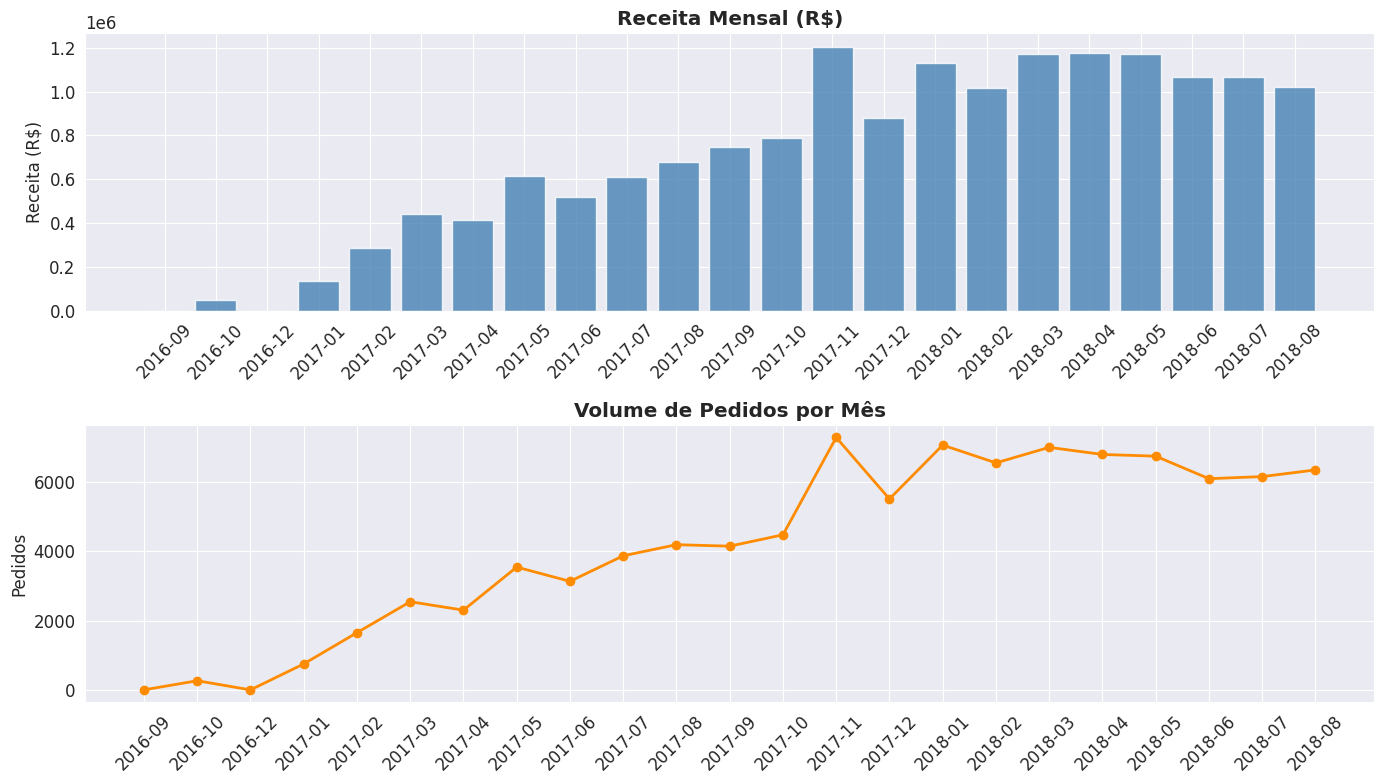

✅ receita_mensal.csv exportado (23 linhas)


In [ ]:
# ── 1. Receita Mensal ─────────────────────────────────────────────────────────
df = fato[fato["order_status"] == "delivered"].copy()
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df_mensal = (
    df.groupby(["purchase_year", "purchase_month"])
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("item_total", "sum"),
        ticket_medio=("item_price", "mean"),
        frete_medio=("item_freight", "mean")
    )
    .round(2)
    .reset_index()
    .rename(columns={"purchase_year": "ano", "purchase_month": "mes"})
    .sort_values(["ano", "mes"])
)
df_mensal["periodo"] = (
    df_mensal["ano"].astype(str) + "-" +
    df_mensal["mes"].astype(str).str.zfill(2)
)
df_mensal.to_csv(f"{EXPORT_PATH}/receita_mensal.csv", index=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.bar(df_mensal["periodo"], df_mensal["receita"], color="steelblue", alpha=0.8)
ax1.set_title("Receita Mensal (R$)", fontweight="bold")
ax1.set_ylabel("Receita (R$)")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(df_mensal["periodo"], df_mensal["pedidos"],
         marker="o", color="darkorange", linewidth=2)
ax2.set_title("Volume de Pedidos por Mês", fontweight="bold")
ax2.set_ylabel("Pedidos")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/receita_mensal.png", dpi=150)
plt.show()
print(f"✅ receita_mensal.csv exportado ({len(df_mensal)} linhas)")


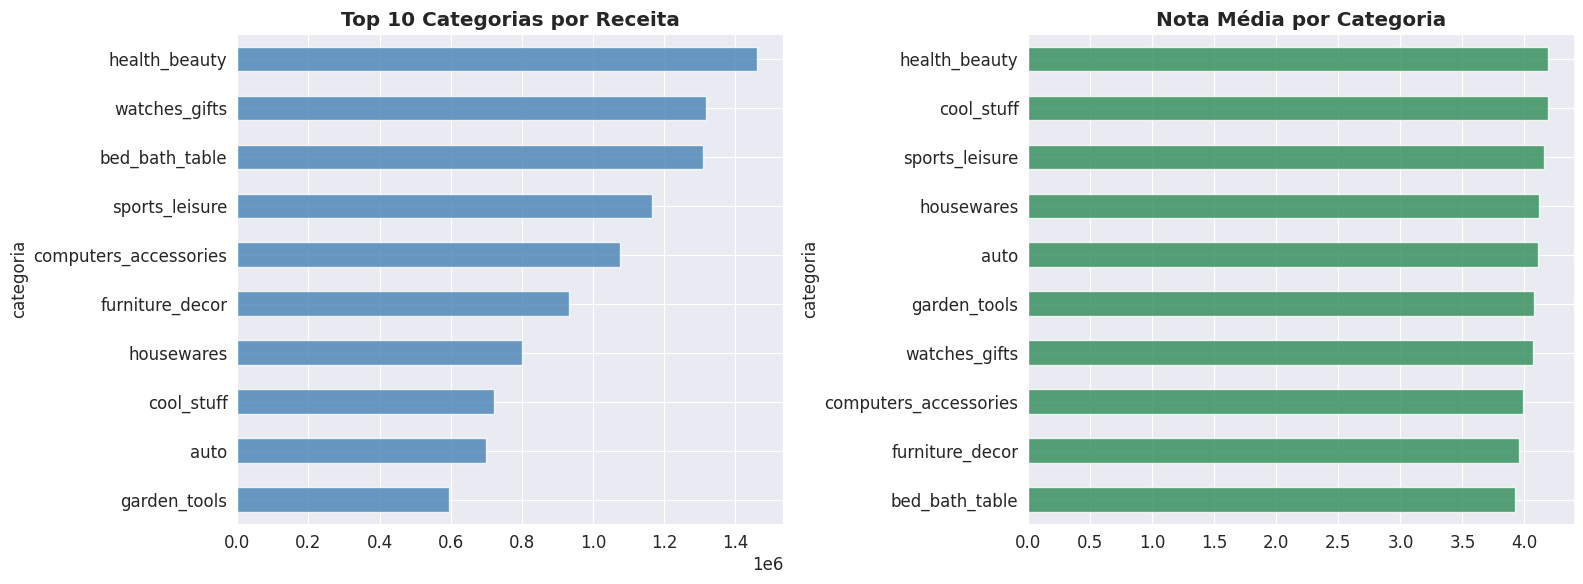

✅ performance_categorias.csv exportado (72 linhas)


In [ ]:
# ── 2. Performance por Categoria ──────────────────────────────────────────────
df_cat = (
    fato[fato["order_status"] == "delivered"]
    .merge(
        produtos[["product_id", "product_category_name_english"]],
        on="product_id", how="left"
    )
)
df_categoria = (
    df_cat
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("item_total", "sum"),
        ticket_medio=("item_price", "mean"),
        nota_media=("review_score", "mean")
    )
    .round(2)
    .reset_index()
    .rename(columns={"product_category_name_english": "categoria"})
    .sort_values("receita", ascending=False)
)
df_categoria.to_csv(f"{EXPORT_PATH}/performance_categorias.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
df_categoria.head(10).sort_values("receita").plot(
    kind="barh", x="categoria", y="receita",
    ax=ax1, color="steelblue", alpha=0.8, legend=False
)
ax1.set_title("Top 10 Categorias por Receita", fontweight="bold")

df_categoria.head(10).sort_values("nota_media").plot(
    kind="barh", x="categoria", y="nota_media",
    ax=ax2, color="seagreen", alpha=0.8, legend=False
)
ax2.set_title("Nota Média por Categoria", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/performance_categorias.png", dpi=150)
plt.show()
print(f"✅ performance_categorias.csv exportado ({len(df_categoria)} linhas)")

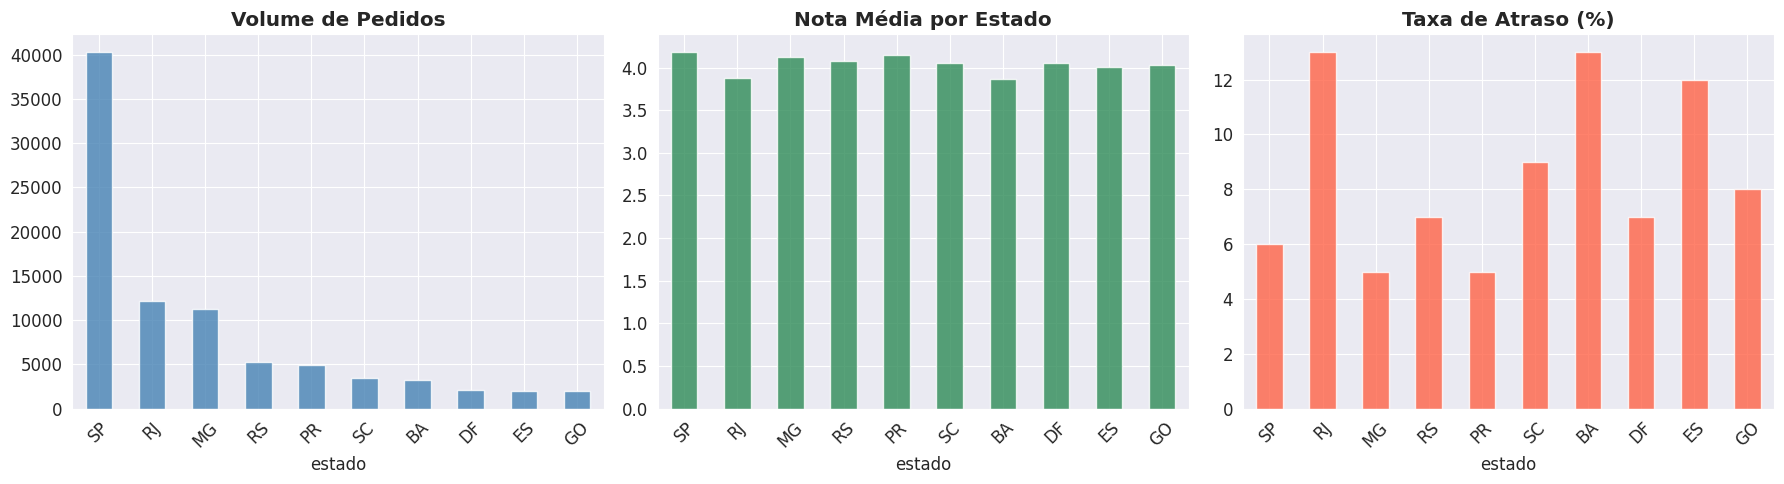

✅ satisfacao_estados.csv exportado (27 linhas)


In [ ]:
# ── 3. Satisfação por Estado ──────────────────────────────────────────────────
df_estado = (
    fato[fato["order_status"] == "delivered"]
    .dropna(subset=["review_score"])
    .groupby("customer_state")
    .agg(
        pedidos=("order_id", "nunique"),
        nota_media=("review_score", "mean"),
        prazo_medio_dias=("delivery_days", "mean"),
        pct_atraso=("is_late", "mean")
    )
    .round(2)
    .reset_index()
    .rename(columns={"customer_state": "estado"})
    .sort_values("pedidos", ascending=False)
)
df_estado["pct_atraso"] = (df_estado["pct_atraso"] * 100).round(1)
df_estado.to_csv(f"{EXPORT_PATH}/satisfacao_estados.csv", index=False)

df_top = df_estado.head(10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_top.plot(kind="bar", x="estado", y="pedidos",
            ax=axes[0], color="steelblue", alpha=0.8, legend=False)
axes[0].set_title("Volume de Pedidos", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

df_top.plot(kind="bar", x="estado", y="nota_media",
            ax=axes[1], color="seagreen", alpha=0.8, legend=False)
axes[1].set_title("Nota Média por Estado", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

df_top.plot(kind="bar", x="estado", y="pct_atraso",
            ax=axes[2], color="tomato", alpha=0.8, legend=False)
axes[2].set_title("Taxa de Atraso (%)", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/satisfacao_estados.png", dpi=150)
plt.show()
print(f"✅ satisfacao_estados.csv exportado ({len(df_estado)} linhas)")

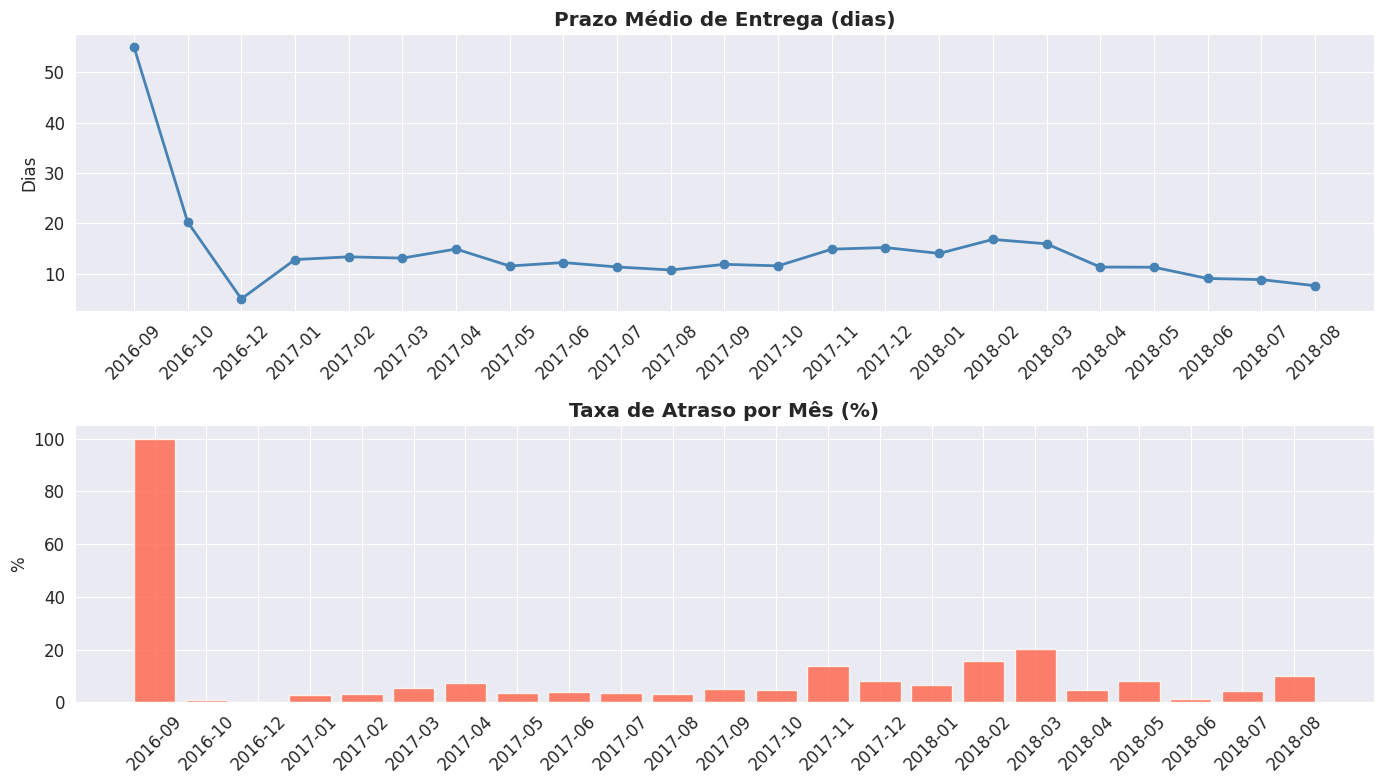

✅ tempo_entrega.csv exportado (23 linhas)


In [ ]:
# ── 4. Tempo de Entrega ───────────────────────────────────────────────────────
df_entrega = (
    fato[
        (fato["order_status"] == "delivered") &
        (fato["delivery_days"].notna()) &
        (fato["delivery_days"] > 0)
    ]
    .groupby(["purchase_year", "purchase_month"])
    .agg(
        prazo_medio=("delivery_days", "mean"),
        prazo_minimo=("delivery_days", "min"),
        prazo_maximo=("delivery_days", "max"),
        atrasados=("is_late", "sum"),
        total_entregas=("order_id", "count"),
        pct_atraso=("is_late", "mean")
    )
    .round(3)
    .reset_index()
    .rename(columns={"purchase_year": "ano", "purchase_month": "mes"})
    .sort_values(["ano", "mes"])
)
df_entrega["periodo"] = (
    df_entrega["ano"].astype(str) + "-" +
    df_entrega["mes"].astype(str).str.zfill(2)
)
df_entrega["pct_atraso"] = (df_entrega["pct_atraso"] * 100).round(1)
df_entrega.to_csv(f"{EXPORT_PATH}/tempo_entrega.csv", index=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.plot(df_entrega["periodo"], df_entrega["prazo_medio"],
         marker="o", color="steelblue", linewidth=2)
ax1.set_title("Prazo Médio de Entrega (dias)", fontweight="bold")
ax1.set_ylabel("Dias")
ax1.tick_params(axis="x", rotation=45)

ax2.bar(df_entrega["periodo"], df_entrega["pct_atraso"],
        color="tomato", alpha=0.8)
ax2.set_title("Taxa de Atraso por Mês (%)", fontweight="bold")
ax2.set_ylabel("%")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/tempo_entrega.png", dpi=150)
plt.show()
print(f"✅ tempo_entrega.csv exportado ({len(df_entrega)} linhas)")


In [ ]:
# ── 5. Performance de Vendedores (Top 50) ─────────────────────────────────────
df_sell = (
    fato[fato["order_status"] == "delivered"]
    .merge(
        sellers[["seller_id", "seller_state", "seller_city"]],
        on="seller_id", how="left"
    )
    .groupby(["seller_id", "seller_state", "seller_city"])
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("item_total", "sum"),
        ticket_medio=("item_price", "mean"),
        nota_media=("review_score", "mean"),
        pct_atraso=("is_late", "mean")
    )
    .round(2)
    .reset_index()
    .rename(columns={"seller_state": "estado", "seller_city": "cidade"})
)
df_sell["pct_atraso"] = (df_sell["pct_atraso"] * 100).round(1)
df_sell = df_sell[df_sell["pedidos"] >= 10].sort_values("receita", ascending=False).head(50)
df_sell.to_csv(f"{EXPORT_PATH}/performance_vendedores.csv", index=False)
print(f"✅ performance_vendedores.csv exportado ({len(df_sell)} linhas)")


✅ performance_vendedores.csv exportado (50 linhas)


In [ ]:
# ── Resumo e download dos CSVs ────────────────────────────────────────────────
print("=" * 60)
print("PIPELINE ETL — CONCLUÍDO")
print("=" * 60)

csvs = sorted([f for f in os.listdir(EXPORT_PATH) if f.endswith(".csv")])
print(f"\n📁 CSVs gerados ({len(csvs)}):")
for f in csvs:
    size = os.path.getsize(f"{EXPORT_PATH}/{f}") / 1024
    print(f"   └── {f:<45} {size:>6.1f} KB")

receita_total = fato[fato["order_status"] == "delivered"]["item_total"].sum()
pedidos_total = fato[fato["order_status"] == "delivered"]["order_id"].nunique()
nota_media    = fato["review_score"].mean()
taxa_atraso   = fato[fato["order_status"] == "delivered"]["is_late"].mean() * 100

print(f"""
{'='*60}
MÉTRICAS FINAIS
{'='*60}
   Receita total:     R$ {receita_total:>12,.2f}
   Pedidos entregues: {pedidos_total:>12,}
   Nota média:        {nota_media:>12.2f} / 5.00
   Taxa de atraso:    {taxa_atraso:>11.1f}%
{'='*60}
""")

# Download automático dos CSVs
print("📥 Iniciando download dos CSVs...")
print("   Salve-os em dashboard/data/ no seu repositório.\n")
from google.colab import files
for f in csvs:
    files.download(f"{EXPORT_PATH}/{f}")
    print(f"   ⬇️  {f}")

PIPELINE ETL — CONCLUÍDO

📁 CSVs gerados (5):
   └── performance_categorias.csv                       3.0 KB
   └── performance_vendedores.csv                       3.8 KB
   └── receita_mensal.csv                               1.0 KB
   └── satisfacao_estados.csv                           0.7 KB
   └── tempo_entrega.csv                                1.1 KB

MÉTRICAS FINAIS
   Receita total:     R$ 16,188,340.32
   Pedidos entregues:       96,478
   Nota média:                4.02 / 5.00
   Taxa de atraso:            7.8%

📥 Iniciando download dos CSVs...
   Salve-os em dashboard/data/ no seu repositório.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ⬇️  performance_categorias.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ⬇️  satisfacao_estados.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ⬇️  tempo_entrega.csv
